<a href="https://colab.research.google.com/github/ayelencalo/TP_vision_computadora_2/blob/main/Agus_FINAL_TP_Final_Futbol_Deteccion_Tracking_copiaAndy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ⚽ Visión por Computadora II – CEIA – FIUBA
## Trabajo Práctico: Detección de Jugadores, Pelota y Árbitros en Fútbol
### **Grupo 11**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/FIUBA-Posgrado-Inteligencia-Artificial/vision_computadora_II/blob/main/Trabajo_Practico/TP_Final_Futbol_Deteccion_Tracking.ipynb)

---

### 📋 Diagrama de Etapas del Sistema (Fase A: Entrenamiento y Evaluación)
```
[01. Dataset] ────────► [02. EDA y Preproc.] ────────► [03. Fine-tuning YOLO]
 • Kaggle (53k img)       • Limpieza (sin labels)       • Baseline 640
 • 4 clases               • Muestreo 50%                • Variante 1280 (alta res)
 • splits train/val/test  • Conteo & Pelota ~5px        • Variante P2 (objetos chicos)
                          • Data Augmentation           • 15 épocas / save_period=5
                                                               │
                                                               ▼
[06. Video Match] ◄──── [05. Posprocesamiento] ◄───── [04. Evaluación]
 • Inferencia frame-by-   • Conf. Threshold (0.3)      • mAP@50 y mAP@50-95
   frame con OpenCV       • NMS IoU (0.50)              • Matriz de confusión
 • HUD estadístico        • Disputas cuerpo a cuerpo      (Arquero vs. Jugador)
 • Video MP4 exportado                                  • Modelo ganador
```

---
### 🎯 Especificaciones de este Notebook Unificado:
1. **Ejecutable de punta a punta** en **Google Colab** (o localmente) por cualquier usuario.
2. **Curación estricta de datos:** Eliminación de imágenes sin anotaciones (fondos puros vacíos) y **submuestreo determinístico al 50% de la base** para una ejecución ágil y eficiente.
3. **Persistencia y Resiliencia en Colab:**
   * Soporte opcional para guardar checkpoints directamente en **Google Drive**.
   * Guardado cada 5 épocas (`save_period=5`) para permitir reanudar el entrenamiento (`resume=True`) ante desconexiones.
   * Fijación rigurosa de semillas aleatorias (`seed=42`, `deterministic=True`) para garantizar reproducibilidad.
4. **Comparación Formal de los 3 Modelos:**
   * **Modelo 1 (Baseline Baja Resolución):** $640 	imes 640$, pesos preentrenados COCO.
   * **Modelo 2 (Alta Resolución):** $1280 	imes 1280$, para recuperar la pelota pequeña de $pprox 5$ px.
   * **Modelo 3 (Cabeza P2 para Objetos Pequeños):** $640 	imes 640$, arquitectura `yolov8s-p2.yaml` con stride 4.
5. **Evaluación, Posprocesamiento y Video:**
   * Matriz de confusión detallada (arquero vs. jugador de campo).
   * Calibración de umbrales `conf` y `iou` (NMS).
   * Generación de video de partido con HUD informativo en tiempo real.


## 1. Configuración del Entorno, Google Drive y Reproducibilidad

Configuramos las dependencias, inicializamos las semillas pseudoaleatorias para garantizar reproducibilidad matemática y configuramos la ruta de persistencia (con opción de montar Google Drive si ejecutamos en Colab).


In [4]:
# Verificación de entorno, semillas y configuración de almacenamiento
import sys
import os
import random
import shutil
from pathlib import Path

# 1. Detección de entorno
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("🚀 Ejecutando en Google Colab")
    get_ipython().system("pip install -q ultralytics kagglehub opencv-python matplotlib seaborn pyyaml")

    # Montaje opcional de Google Drive para persistencia de modelos ante reinicios
    MOUNT_DRIVE = True  # Cambiar a True si deseas persistir directamente en tu Drive personal
    if MOUNT_DRIVE:
        from google.colab import drive
        drive.mount('/content/drive')
        # LECTURA: carpeta compartida del grupo (pesos entrenados, video original)
        SHARED_DIR = Path("/content/drive/MyDrive/CEIA_VpC2_TP")
        # ESCRITURA: carpeta propia de cada integrante (no pisa los resultados compartidos)
        OUT_DIR = Path("/content/drive/MyDrive/VpC2_salidas")
    else:
        SHARED_DIR = Path("/content")
        OUT_DIR = Path("/content/salidas")
else:
    print("💻 Ejecutando en entorno Local")
    if sys.platform == 'win32':
        os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
    SHARED_DIR = Path("Trabajo_Practico")
    OUT_DIR = Path("Trabajo_Practico/salidas")

RUNS_DIR = SHARED_DIR / "runs"          # solo lectura de pesos
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"📁 Pesos (lectura):      {RUNS_DIR}")
print(f"📁 Resultados (escritura): {OUT_DIR}")

# 2. Reproducibilidad: Fijar semillas aleatorias
SEED = 42
random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

import torch
import numpy as np
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

import cv2
from ultralytics import YOLO
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from tqdm import tqdm
import kagglehub

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_theme(style="whitegrid")

DEVICE = "0" if torch.cuda.is_available() else "cpu"
print(f"\nDispositivo PyTorch: {DEVICE}")
if torch.cuda.is_available():
    print(f" - GPU: {torch.cuda.get_device_name(0)}")
    print(f" - VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
print(f"Semilla de reproducibilidad fijada: {SEED}")


🚀 Ejecutando en Google Colab
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.1/96.1 kB 10.0 MB/s eta 0:00:00
Mounted at /content/drive
📁 Pesos (lectura):      /content/drive/MyDrive/CEIA_VpC2_TP/runs
📁 Resultados (escritura): /content/drive/MyDrive/VpC2_salidas
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.

Dispositivo PyTorch: 0
 - GPU: Tesla T4
 - VRAM: 15.64 GB
Semilla de reproducibilidad fijada: 42


In [5]:
# Verificación: ¿se ven los pesos y el video compartidos?
SHARED = Path("/content/drive/MyDrive/CEIA_VpC2_TP")
for rel in ["runs/train/m1_baseline_640/weights/best.pt",
            "runs/train/m2_highres_1280/weights/best.pt",
            "runs/train/m3_p2_head_640/weights/best.pt",
            "data/sample_match_15s.mp4"]:
    p = SHARED / rel
    print("OK  " if p.exists() else "FALTA", rel)

OK   runs/train/m1_baseline_640/weights/best.pt
OK   runs/train/m2_highres_1280/weights/best.pt
OK   runs/train/m3_p2_head_640/weights/best.pt
OK   data/sample_match_15s.mp4


## 2. Etapa 01: Descarga y Preparación del Dataset

Descargamos automáticamente el dataset oficial desde Kaggle:
* **Dataset:** [`oussamamoussa/foot-ball-dataset`](https://www.kaggle.com/datasets/oussamamoussa/foot-ball-dataset)
* **Formato:** YOLO estándar (anotaciones normalizadas `[class_id, xc, yc, w, h]`).
* **Clases de interés:**
  * `0: ball` (pelota)
  * `1: goalkeeper` (arquero)
  * `2: player` (jugador de campo)
  * `3: referee` (árbitro)

Utilizamos `kagglehub.dataset_download`, que descarga datasets públicos sin requerir credenciales manuales complejas.


In [7]:
# Descarga o localización automática del dataset
DATASET_HANDLE = "oussamamoussa/foot-ball-dataset"

local_candidates = [
    Path("Trabajo_Practico/data/football_dataset"),
    Path("data/football_dataset"),
    Path("../data/football_dataset"),
    Path(os.path.expanduser("~/.cache/kagglehub/datasets/oussamamoussa/foot-ball-dataset/versions/1"))
]

dataset_path = None
for candidate in local_candidates:
    if candidate.exists() and (candidate / "train" / "images").exists():
        dataset_path = candidate.resolve()
        print(f" Dataset encontrado localmente en: {dataset_path}")
        break

if dataset_path is None:
    print(f"📥 Descargando dataset desde Kaggle ({DATASET_HANDLE})...")
    downloaded_dir = kagglehub.dataset_download(DATASET_HANDLE)
    dataset_path = Path(downloaded_dir).resolve()
    print(f" Dataset descargado exitosamente en: {dataset_path}")

print(f"\nRuta base del dataset: {dataset_path}")


📥 Descargando dataset desde Kaggle (oussamamoussa/foot-ball-dataset)...


100%|██████████| 3.72G/3.72G [00:49<00:00, 81.4MB/s]

Extracting files...


 Dataset descargado exitosamente en: /root/.cache/kagglehub/datasets/oussamamoussa/foot-ball-dataset/versions/1

Ruta base del dataset: /root/.cache/kagglehub/datasets/oussamamoussa/foot-ball-dataset/versions/1


## 3. Curación de Datos: Eliminación de Imágenes sin Etiqueta y Submuestreo al 50%

### 🧹 Requerimientos del Preprocesamiento:
1. **Eliminación de Imágenes Vacías:** En la base original existen imágenes sin ninguna anotación (archivo `.txt` de tamaño 0 bytes o vacío). En un partido de fútbol profesional es imposible que no haya ni jugadores, ni arqueros, ni árbitros ni pelota. Por ende, **filtramos y eliminamos todas las imágenes sin anotaciones**.
2. **Submuestreo al 50%:** Para lograr una experimentación ágil y permitir comparar 3 arquitecturas de modelos en tiempos razonables de Colab, seleccionamos exactamente el **50% de las imágenes con anotaciones válidas** en cada split, empleando `random.seed(42)`.


In [8]:
# Filtrado de imágenes vacías y generación de split al 50%
splits_dir = Path("splits_50pct") if IN_COLAB else Path("Trabajo_Practico/data/splits_50pct")
splits_dir.mkdir(parents=True, exist_ok=True)

class_names = ["ball", "goalkeeper", "player", "referee"]
subsample_records = []
split_files_map = {}

random.seed(SEED)

for split in ["train", "valid", "test"]:
    img_dir = dataset_path / split / "images"
    lbl_dir = dataset_path / split / "labels"

    valid_img_paths = []
    empty_label_count = 0
    missing_count = 0

    # Recorrido ultra-rápido de entradas de directorio
    with os.scandir(img_dir) as entries:
        for entry in entries:
            if entry.is_file() and entry.name.lower().endswith((".jpg", ".png", ".jpeg")):
                lbl_file = lbl_dir / f"{Path(entry.name).stem}.txt"
                if not lbl_file.exists():
                    missing_count += 1
                elif lbl_file.stat().st_size == 0:
                    empty_label_count += 1
                else:
                    # Validar que tenga al menos una línea con contenido
                    valid_img_paths.append(str(Path(entry.path).resolve()).replace("\\", "/"))

    total_imgs = len(valid_img_paths) + empty_label_count + missing_count

    # Ordenar determinísticamente antes de barajar
    valid_img_paths.sort()
    random.shuffle(valid_img_paths)

    # Seleccionar exactamente el 50%
    n_sample = len(valid_img_paths) // 2
    sampled_50pct = valid_img_paths[:n_sample]

    # Guardar lista de rutas de imágenes
    split_txt = splits_dir / f"{split}_50pct.txt"
    with open(split_txt, "w", encoding="utf-8") as f:
        f.write("\n".join(sampled_50pct) + "\n")

    split_files_map[split] = split_txt.resolve()

    subsample_records.append({
        "Split": split,
        "Total Original": total_imgs,
        "Sin Etiqueta (Eliminadas)": empty_label_count,
        "Válidas con Anotación": len(valid_img_paths),
        "50% Seleccionado para TP": len(sampled_50pct)
    })

df_curacion = pd.DataFrame(subsample_records)
print("📊 Resumen de Limpieza y Submuestreo al 50%:")
display(df_curacion)

total_eliminadas = df_curacion["Sin Etiqueta (Eliminadas)"].sum()
total_entrenamiento_50 = df_curacion["50% Seleccionado para TP"].sum()
print(f"\n Total de imágenes vacías eliminadas: {total_eliminadas:,}")
print(f" Total de imágenes en el dataset final (50% curado): {total_entrenamiento_50:,}")


📊 Resumen de Limpieza y Submuestreo al 50%:


,Split,Total Original,Sin Etiqueta (Eliminadas),Válidas con Anotación,50% Seleccionado para TP
0,train,46511,2162,44349,22174
1,valid,4757,317,4440,2220
2,test,2177,141,2036,1018



 Total de imágenes vacías eliminadas: 2,620
 Total de imágenes en el dataset final (50% curado): 25,412


### 3.1 Configuración de `data_football_50pct.yaml` para Ultralytics YOLO

Ultralytics YOLO permite especificar un archivo `.txt` con la lista de imágenes para cada split. Generamos el archivo de configuración correspondiente apuntando a nuestras listas del 50%.


In [9]:
# Generación del archivo YAML definitivo del dataset curado
yaml_50pct_config = {
    "path": str(dataset_path).replace("\\", "/"),
    "train": str(split_files_map["train"]).replace("\\", "/"),
    "val": str(split_files_map["valid"]).replace("\\", "/"),
    "test": str(split_files_map["test"]).replace("\\", "/"),
    "nc": len(class_names),
    "names": {i: name for i, name in enumerate(class_names)}
}

yaml_50pct_path = Path("data_football_50pct.yaml") if IN_COLAB else Path("Trabajo_Practico/configs/data_football_50pct.yaml")
yaml_50pct_path.parent.mkdir(parents=True, exist_ok=True)

with open(yaml_50pct_path, "w", encoding="utf-8") as f:
    yaml.dump(yaml_50pct_config, f, sort_keys=False, default_flow_style=False)

print(f" Configuración guardada en: {yaml_50pct_path.resolve()}")
print(yaml.dump(yaml_50pct_config, default_flow_style=False))


 Configuración guardada en: /content/data_football_50pct.yaml
names:
  0: ball
  1: goalkeeper
  2: player
  3: referee
nc: 4
path: /root/.cache/kagglehub/datasets/oussamamoussa/foot-ball-dataset/versions/1
test: /content/splits_50pct/test_50pct.txt
train: /content/splits_50pct/train_50pct.txt
val: /content/splits_50pct/valid_50pct.txt



## 4. Etapa 02: Análisis Exploratorio de Datos (EDA) y Preprocesamiento

Analizamos las características estadísticas y espaciales del dataset curado:
1. **Conteo por clase:** Cuantificación del desbalance (`player >> resto`).
2. **Dimensiones de Bounding Boxes:** Demostración de que la **pelota tiene $\approx 5$ px de lado (mediana a 640x640)**.
3. **Distribución espacial:** Heatmaps de posiciones de jugadores y pelota en el campo.
4. **Visualización cualitativa:** Cuadros anotados con colores por rol y zoom sobre la pelota.
5. **Estrategia de Data Augmentation:** Transformaciones permitidas vs. desaconsejadas en fútbol.


In [ ]:
# Extracción de estadísticas de anotaciones en el conjunto de validación curado
def extract_box_statistics(image_list_txt, max_samples=2000):
    with open(image_list_txt, "r", encoding="utf-8") as f:
        img_paths = [p.strip() for p in f if p.strip()]
    if max_samples:
        img_paths = img_paths[:max_samples]

    box_records = []
    for img_p_str in tqdm(img_paths, desc="Analizando Bounding Boxes"):
        img_p = Path(img_p_str)
        lbl_p = img_p.parent.parent / "labels" / f"{img_p.stem}.txt"
        if not lbl_p.exists():
            continue

        with open(lbl_p, "r", encoding="utf-8") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    cls_id = int(parts[0])
                    xc, yc, w, h = map(float, parts[1:5])
                    box_records.append({
                        "image": img_p.stem,
                        "class_id": cls_id,
                        "class_name": class_names[cls_id] if cls_id < len(class_names) else f"cls_{cls_id}",
                        "xc": xc,
                        "yc": yc,
                        "w": w,
                        "h": h,
                        "w_px_640": w * 640,
                        "h_px_640": h * 640,
                        "area_rel": w * h,
                        "aspect_ratio": h / (w + 1e-6)
                    })
    return pd.DataFrame(box_records)

df_boxes_eda = extract_box_statistics(split_files_map["valid"])
print(f"\nTotal de objetos analizados en validación: {len(df_boxes_eda):,}")
display(df_boxes_eda.head())


Analizando Bounding Boxes: 100%|██████████| 2000/2000 [00:01<00:00, 1028.01it/s]



Total de objetos analizados en validación: 37,118


,image,class_id,class_name,xc,yc,w,h,w_px_640,h_px_640,area_rel,aspect_ratio
0,ds45_744b27_3_7_png_jpg.rf.7017bc606f434a1281f...,2,player,0.752344,0.427344,0.007812,0.028906,5.0,18.5,0.000226,3.699526
1,ds45_744b27_3_7_png_jpg.rf.7017bc606f434a1281f...,2,player,0.337500,0.432812,0.007812,0.035156,5.0,22.5,0.000275,4.499424
2,ds45_744b27_3_7_png_jpg.rf.7017bc606f434a1281f...,2,player,0.373437,0.429688,0.011719,0.033594,7.5,21.5,0.000394,2.866422
3,ds45_744b27_3_7_png_jpg.rf.7017bc606f434a1281f...,2,player,0.390625,0.446875,0.012500,0.035156,8.0,22.5,0.000439,2.812275
4,ds45_744b27_3_7_png_jpg.rf.7017bc606f434a1281f...,2,player,0.659375,0.492188,0.009375,0.039062,6.0,25.0,0.000366,4.166222


### 4.1 Distribución de Clases y Severo Desbalance (`player >> resto`)


,Instancias,Porcentaje (%),Ratio vs Pelota
class_name,,,
ball,1588,4.28,1.00
goalkeeper,919,2.48,0.58
player,31829,85.75,20.04
referee,2782,7.50,1.75


/tmp/ipykernel_1266/498552045.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts_by_class.index, y=counts_by_class.values, palette=palette, ax=axes[0])
/tmp/ipykernel_1266/498552045.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts_by_class.index, y=counts_by_class.values, palette=palette, ax=axes[1])


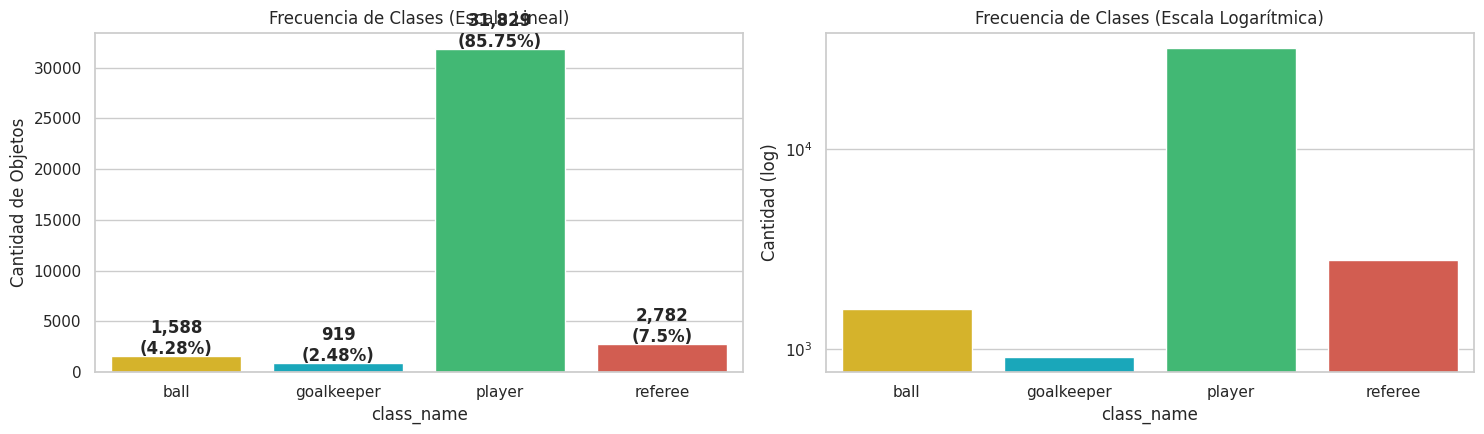

In [ ]:
# Análisis cuantitativo del desbalance de clases
counts_by_class = df_boxes_eda["class_name"].value_counts().reindex(class_names).fillna(0).astype(int)
pcts_by_class = (counts_by_class / counts_by_class.sum() * 100).round(2)

df_class_dist = pd.DataFrame({
    "Instancias": counts_by_class,
    "Porcentaje (%)": pcts_by_class,
    "Ratio vs Pelota": (counts_by_class / max(1, counts_by_class["ball"])).round(2)
})
display(df_class_dist)

# Visualización gráfica de distribución
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
palette = ["#f1c40f", "#00bcd4", "#2ecc71", "#e74c3c"]

sns.barplot(x=counts_by_class.index, y=counts_by_class.values, palette=palette, ax=axes[0])
axes[0].set_title("Frecuencia de Clases (Escala Lineal)")
axes[0].set_ylabel("Cantidad de Objetos")
for i, v in enumerate(counts_by_class.values):
    axes[0].text(i, v + 200, f"{v:,}\n({pcts_by_class.iloc[i]}%)", ha="center", fontweight="bold")

sns.barplot(x=counts_by_class.index, y=counts_by_class.values, palette=palette, ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Frecuencia de Clases (Escala Logarítmica)")
axes[1].set_ylabel("Cantidad (log)")

plt.tight_layout()
plt.show()


### 4.2 Dimensiones de Bounding Boxes y Confirmación de la Pelota Pequeña (~5 px)


In [ ]:
# Cálculo de dimensiones medianas relativas a 640x640
dim_stats = []
for c in class_names:
    sub = df_boxes_eda[df_boxes_eda["class_name"] == c]
    if len(sub) == 0:
        continue
    dim_stats.append({
        "Clase": c,
        "Ancho Mediano (px@640)": round(sub["w_px_640"].median(), 2),
        "Alto Mediano (px@640)": round(sub["h_px_640"].median(), 2),
        "Lado Promedio (px@640)": round(((sub["w_px_640"] + sub["h_px_640"]) / 2).median(), 2),
        "Aspect Ratio Mediano (h/w)": round(sub["aspect_ratio"].median(), 2)
    })

df_dim = pd.DataFrame(dim_stats)
display(df_dim)

ball_lado = df_dim.loc[df_dim["Clase"] == "ball", "Lado Promedio (px@640)"].values[0]
print(f"📌 Confirmación empírica: Lado mediano de la pelota = {ball_lado:.2f} px (≈ 5 px a 640x640).")

,Clase,Ancho Mediano (px@640),Alto Mediano (px@640),Lado Promedio (px@640),Aspect Ratio Mediano (h/w)
0,ball,4.0,7.50,5.79,1.78
1,goalkeeper,9.0,30.93,19.75,3.50
2,player,9.0,35.00,22.00,3.82
3,referee,9.0,33.00,20.75,3.75


📌 Confirmación empírica: Lado mediano de la pelota = 5.79 px (≈ 5 px a 640x640).


### 4.3 Visualización Cualitativa y Zoom sobre la Pelota


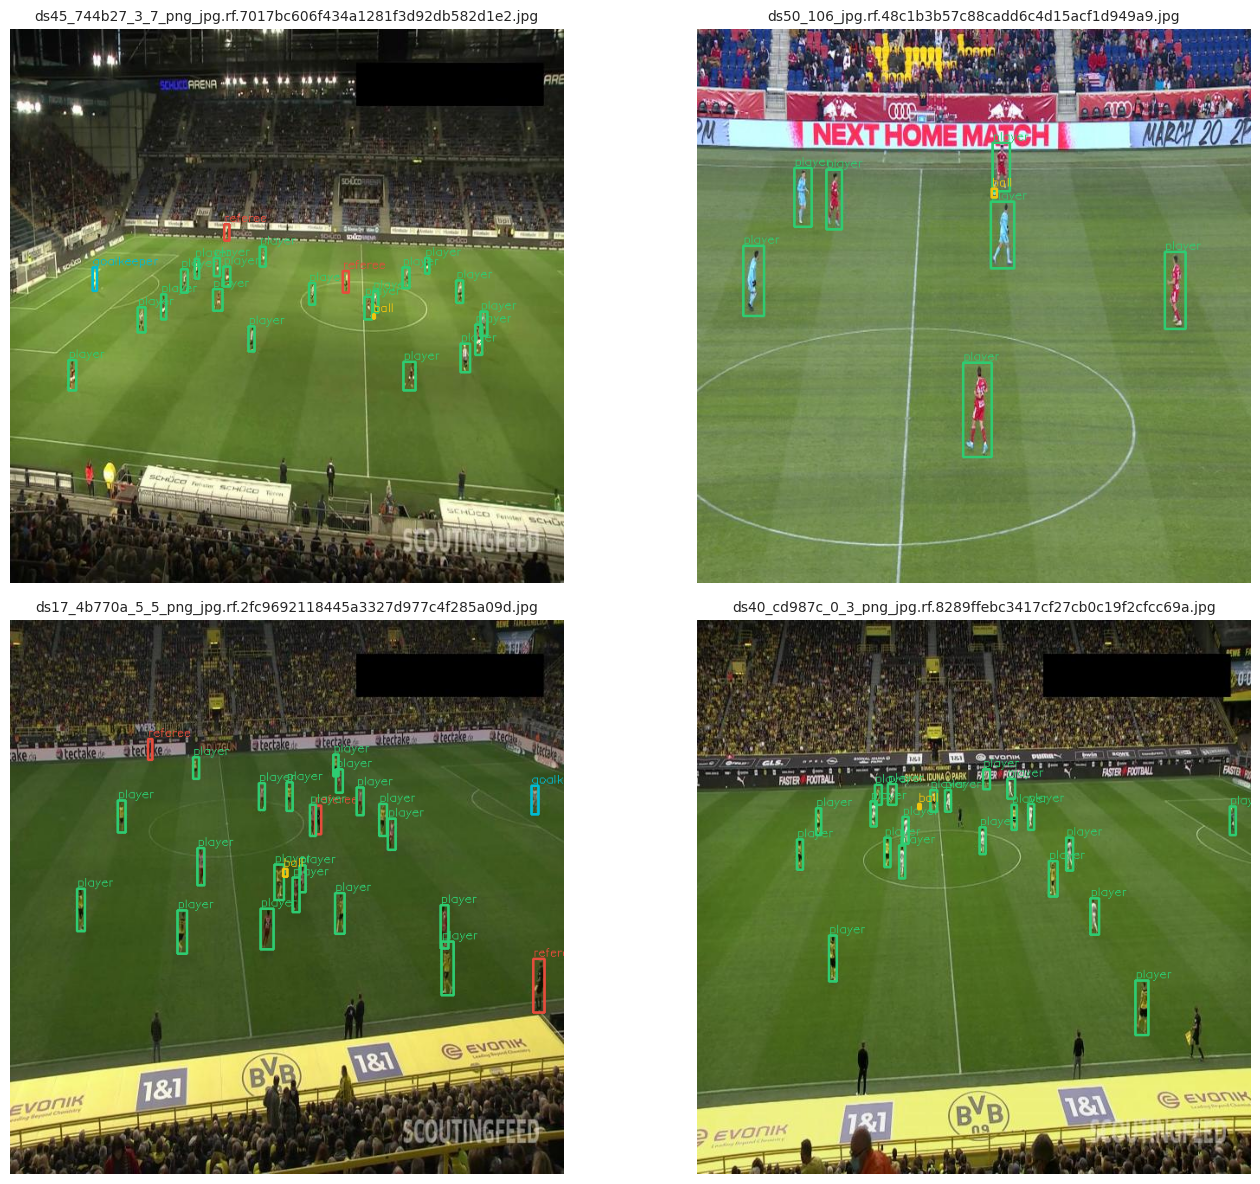

In [ ]:
# Función de visualización cualitativa con bounding boxes
CLASS_COLORS_RGB = {
    0: (241, 196, 15),   # ball: Amarillo
    1: (0, 188, 212),    # goalkeeper: Cian
    2: (46, 204, 113),   # player: Verde
    3: (231, 76, 60)     # referee: Rojo
}

def render_sample(img_path_str, ax=None):
    img_p = Path(img_path_str)
    lbl_p = img_p.parent.parent / "labels" / f"{img_p.stem}.txt"

    img = cv2.imread(str(img_p))
    if img is None:
        return None, None
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img_rgb.shape[:2]

    ball_box = None
    if lbl_p.exists():
        with open(lbl_p, "r", encoding="utf-8") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    cls_id = int(parts[0])
                    xc, yc, bw, bh = map(float, parts[1:5])
                    xmin = max(0, int((xc - bw / 2.0) * w))
                    ymin = max(0, int((yc - bh / 2.0) * h))
                    xmax = min(w - 1, int((xc + bw / 2.0) * w))
                    ymax = min(h - 1, int((yc + bh / 2.0) * h))

                    color = CLASS_COLORS_RGB.get(cls_id, (255, 255, 255))
                    cv2.rectangle(img_rgb, (xmin, ymin), (xmax, ymax), color, 2)
                    c_name = class_names[cls_id]
                    cv2.putText(img_rgb, c_name, (xmin, max(12, ymin - 3)), cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1)

                    if cls_id == 0:
                        ball_box = (xmin, ymin, xmax, ymax)

    if ax:
        ax.imshow(img_rgb)
        ax.axis("off")
        ax.set_title(img_p.name, fontsize=10)
    return img_rgb, ball_box

# Mostrar 4 muestras aleatorias de validación
with open(split_files_map["valid"], "r", encoding="utf-8") as f:
    sample_imgs = [p.strip() for p in f if p.strip()][:4]

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
for i, s_p in enumerate(sample_imgs):
    render_sample(s_p, ax=axes.flatten()[i])
plt.tight_layout()
plt.show()


## 5. Etapa 03: Fine-Tuning YOLO – Comparación de 3 Modelos

Para responder rigurosamente a la problemática planteada en el plan, entrenamos y comparamos **3 configuraciones técnicas**:

| Modelo | Resolución | Arquitectura | Justificación Técnica |
| :--- | :---: | :---: | :--- |
| **Modelo 1 (Baseline)** | $640 	imes 640$ | `yolov8s.pt` | Punto de partida para medir precisión, recall y latencia (FPS). |
| **Modelo 2 (Alta Resolución)** | $1280 	imes 1280$ | `yolov8s.pt` | Duplica la densidad de píxeles: la pelota pasa de ~5 px a ~10 px. |
| **Modelo 3 (Cabeza P2)** | $640 	imes 640$ | `yolov8s-p2.yaml` | Agrega un detector de $stride=4$ ($160 	imes 160$) para objetos diminutos sin duplicar la resolución. |

---
### ⚙️ Parámetros de Entrenamiento Unificados:
* **Épocas:** **15 épocas** (`epochs=15`).
* **Persistencia por Checkpoint:** **Cada 5 épocas** (`save_period=5`), guardando `epoch5.pt`, `epoch10.pt`, `epoch15.pt`, `last.pt` y `best.pt`.
* **Resiliencia ante desconexiones:** Soporte para reanudar el entrenamiento con `resume=True`.
* **Semilla fija:** `seed=42`, `deterministic=True`.


In [ ]:
# Configuración unificada de entrenamiento para los 3 modelos (15 épocas)
BASE_TRAIN_PARAMS = {
    "data": str(yaml_50pct_path.resolve()),
    "epochs": 15,                  # 15 épocas requeridas
    "save_period": 5,              # Checkpoint de persistencia cada 5 épocas
    "project": str(RUNS_DIR / "train"),
    "seed": SEED,                  # Semilla de reproducibilidad (42)
    "deterministic": True,         # Determinismo en PyTorch
    "save": True,
    "patience": 8,                 # Early stopping
    "exist_ok": True,
    # Data Augmentation adaptado para fútbol:
    "fliplr": 0.5,                 # Flip horizontal simétrico
    "flipud": 0.0,                 # Flip vertical desactivado (gravedad fija)
    "hsv_h": 0.015,
    "hsv_s": 0.7,
    "hsv_v": 0.4,
    "mosaic": 1.0,
    "close_mosaic": 3              # Desactivar mosaico en últimas 3 épocas para estabilizar cajas
}

print("Parámetros de entrenamiento base listos:")
for k, v in BASE_TRAIN_PARAMS.items():
    print(f"  • {k}: {v}")


Parámetros de entrenamiento base listos:
  • data: /content/data_football_50pct.yaml
  • epochs: 15
  • save_period: 5
  • project: /content/drive/MyDrive/CEIA_VpC2_TP/runs/train
  • seed: 42
  • deterministic: True
  • save: True
  • patience: 8
  • exist_ok: True
  • fliplr: 0.5
  • flipud: 0.0
  • hsv_h: 0.015
  • hsv_s: 0.7
  • hsv_v: 0.4
  • mosaic: 1.0
  • close_mosaic: 3


### 5.1 Reanudación de Entrenamiento ante Desconexión (`resume=True`)

Si Google Colab se desconecta durante el entrenamiento, se puede retomar desde el último checkpoint (`last.pt` o `epochX.pt`) ejecutando la siguiente celda:


In [ ]:
# Ejemplo: Cómo reanudar un entrenamiento interrumpido
def resume_training_if_interrupted(checkpoint_path):
    """Reanuda el entrenamiento de YOLO desde el último checkpoint guardado."""
    if Path(checkpoint_path).exists():
        print(f"🔄 Reanudando entrenamiento desde checkpoint: {checkpoint_path}")
        model_resume = YOLO(checkpoint_path)
        model_resume.train(resume=True)
    else:
        print(f"No se encontró checkpoint en {checkpoint_path}. Iniciando desde cero.")


In [ ]:
# Ejecutar si se desconecta la T4 / L4 del colab
# checkpoint_path = str(RUNS_DIR / "train" / "m2_highres_1280" / "weights" / "last.pt")
# resume_training_if_interrupted(checkpoint_path)

### 5.2 Entrenamiento del Modelo 1: Baseline Baja Resolución (640x640)


In [ ]:
# # Modelo 1: Baseline a 640x640
# print("==================================================")
# print("INICIANDO ENTRENAMIENTO: Modelo 1 (Baseline 640)")
# print("==================================================")

# model_1 = YOLO("yolov8s.pt")

# results_m1 = model_1.train(
#     **BASE_TRAIN_PARAMS,
#     imgsz=640,
#     batch=16,
#     name="m1_baseline_640",
#     device=DEVICE
# )

# best_m1_path = RUNS_DIR / "train" / "m1_baseline_640" / "weights" / "best.pt"
# print(f" Pesos Modelo 1 listos en: {best_m1_path}")


### 5.3 Entrenamiento del Modelo 2: Alta Resolución (1280x1280)

Entrenamos a $1280 \times 1280$ para evaluar el impacto de duplicar la resolución en la detección de la pelota diminuta. Se mantuvo `batch=16`, igual que en los otros dos modelos, para que la comparación sea justa.


In [ ]:
# Modelo 2: Alta Resolución (1280x1280)
# print("==================================================")
# print("INICIANDO ENTRENAMIENTO: Modelo 2 (Alta Res 1280)")
# print("==================================================")

# model_2 = YOLO("yolov8s.pt")

# results_m2 = model_2.train(
#     **BASE_TRAIN_PARAMS,
#     imgsz=1280,
#     batch=16,                       # Mismo batch que M1 y M3 para comparar en igualdad de condiciones
#     name="m2_highres_1280",
#     device=DEVICE
# )

# best_m2_path = RUNS_DIR / "train" / "m2_highres_1280" / "weights" / "best.pt"
# print(f" Pesos Modelo 2 listos en: {best_m2_path}")


### 5.4 Entrenamiento del Modelo 3: Cabeza Detectora P2 (Stride 4)

Instanciamos la arquitectura `yolov8s-p2.yaml` y transferimos los pesos preentrenados de COCO.


In [ ]:
# Modelo 3: Arquitectura con Cabeza P2 para Objetos Pequeños
# print("==================================================")
# print("INICIANDO ENTRENAMIENTO: Modelo 3 (Cabeza P2)")
# print("==================================================")

# model_3 = YOLO("yolov8s-p2.yaml")
# model_3.load("yolov8s.pt")  # Transferencia de pesos COCO

# results_m3 = model_3.train(
#     **BASE_TRAIN_PARAMS,
#     imgsz=640,
#     batch=16,
#     name="m3_p2_head_640",
#     device=DEVICE
# )

# best_m3_path = RUNS_DIR / "train" / "m3_p2_head_640" / "weights" / "best.pt"
# print(f" Pesos Modelo 3 listos en: {best_m3_path}")


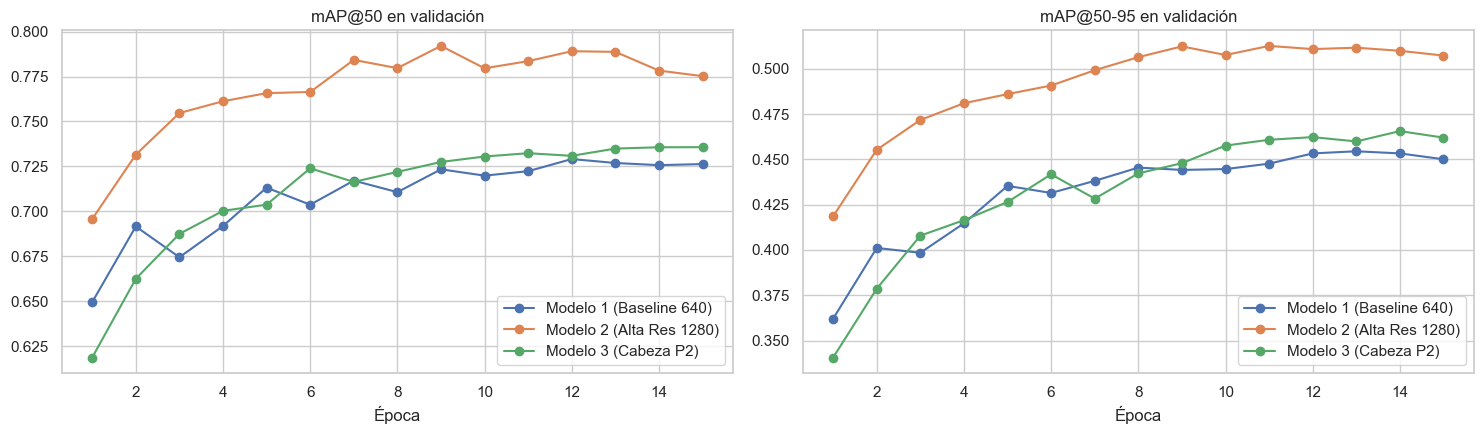

In [14]:
# Curvas de entrenamiento: mAP de validación por época para los 3 modelos

runs = {
    "Modelo 1 (Baseline 640)":  "m1_baseline_640",
    "Modelo 2 (Alta Res 1280)": "m2_highres_1280",
    "Modelo 3 (Cabeza P2)":     "m3_p2_head_640",
}

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
for label, name in runs.items():
    df = pd.read_csv(RUNS_DIR / "train" / name / "results.csv")
    df.columns = df.columns.str.strip()
    axes[0].plot(df["epoch"], df["metrics/mAP50(B)"], marker="o", label=label)
    axes[1].plot(df["epoch"], df["metrics/mAP50-95(B)"], marker="o", label=label)

for ax, titulo in zip(axes, ["mAP@50 en validación", "mAP@50-95 en validación"]):
    ax.set_title(titulo)
    ax.set_xlabel("Época")
    ax.legend()
plt.tight_layout()
plt.show()

Se observan todos los modelos en zona de meseta para el final de las épocas. Además se ve la clara superioridad del modelo 2 en maP@50 respecto a M1 y M3.

## 6. Etapa 04: Evaluación Formal y Comparación de Modelos

Validamos formalmente las 3 variantes sobre el conjunto de validación para responder:
* ¿Mejora la alta resolución (1280) el mAP de la pelota frente al baseline 640?
* ¿Logra la cabeza P2 un recall competitivo en la pelota manteniendo una latencia baja a 640?
* ¿Cómo se comportan las matrices de confusión entre **arquero (`goalkeeper`) vs. jugador (`player`)**?


In [10]:
# Evaluación formal de los 3 modelos en val y test
best_m1_path = RUNS_DIR / "train" / "m1_baseline_640" / "weights" / "best.pt"
best_m2_path = RUNS_DIR / "train" / "m2_highres_1280" / "weights" / "best.pt"
best_m3_path = RUNS_DIR / "train" / "m3_p2_head_640" / "weights" / "best.pt"

model_paths = {
    "Modelo 1 (Baseline 640)":  best_m1_path,
    "Modelo 2 (Alta Res 1280)": best_m2_path,
    "Modelo 3 (Cabeza P2)":     best_m3_path,
}
MODEL_IMGSZ = {
    "Modelo 1 (Baseline 640)":  640,
    "Modelo 2 (Alta Res 1280)": 1280,
    "Modelo 3 (Cabeza P2)":     640,
}

# Sin fallback: si faltan pesos, se corta con un mensaje claro
faltantes = [str(p) for p in model_paths.values() if not Path(p).exists()]
if faltantes:
    raise FileNotFoundError(
        "No se encontraron los pesos entrenados:\n  " + "\n  ".join(faltantes) +
        "\nVerificá el acceso directo a CEIA_VpC2_TP en tu Drive (ver README)."
    )

val_results = {}     # (split, modelo) -> objeto de métricas de Ultralytics
eval_tables = {}     # split -> DataFrame comparativo

for split_name in ["val", "test"]:
    rows = []
    for m_name, m_path in model_paths.items():
        print(f"🔍 Evaluando {m_name} en {split_name}...")
        r = YOLO(str(m_path)).val(
            data=str(yaml_50pct_path.resolve()),
            split=split_name,
            imgsz=MODEL_IMGSZ[m_name],
            device=DEVICE,
            plots=True,                      # necesario para que calcule la matriz de confusión
            project="/content/eval",         # local: no ensucia Drive
            name=f"{split_name}_{m_name.split()[1]}",
            exist_ok=True,
            verbose=False,
        )
        val_results[(split_name, m_name)] = r

        # AP por clase mapeado por índice real (no por posición)
        ap50_cls = dict(zip(r.box.ap_class_index.tolist(), r.box.ap50.tolist()))
        ball_pos = r.box.ap_class_index.tolist().index(0)
        _, ball_recall, _, _ = r.box.class_result(ball_pos)

        p, rc = float(r.box.mp), float(r.box.mr)
        rows.append({
            "Modelo": m_name,
            "Precision": p,
            "Recall": rc,
            "F1": 2 * p * rc / (p + rc + 1e-9),
            "mAP@50": float(r.box.map50),
            "mAP@75": float(r.box.map75),
            "mAP@50-95": float(r.box.map),
            "AP50 Ball": ap50_cls.get(0, 0.0),
            "Recall Ball": float(ball_recall),
            "AP50 Goalkeeper": ap50_cls.get(1, 0.0),
            "AP50 Player": ap50_cls.get(2, 0.0),
            "AP50 Referee": ap50_cls.get(3, 0.0),
            "Inferencia (ms/img, batch)": r.speed["inference"],
            "Total (ms/img, batch)": r.speed["preprocess"] + r.speed["inference"] + r.speed["postprocess"],
        })

    eval_tables[split_name] = pd.DataFrame(rows).set_index("Modelo").round(4)
    print(f"\n🏆 TABLA COMPARATIVA – {split_name.upper()}")
    display(eval_tables[split_name])

🔍 Evaluando Modelo 1 (Baseline 640) en val...
Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 11,127,132 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1726.0±700.2 MB/s, size: 73.5 KB)
val: Scanning /root/.cache/kagglehub/datasets/oussamamoussa/foot-ball-dataset/versions/1/valid/labels... 2220 images, 0 backgrounds, 1 corrupt: 100% ━━━━━━━━━━━━ 2220/2220 2.0Kit/s 1.1s
val: /root/.cache/kagglehub/datasets/oussamamoussa/foot-ball-dataset/versions/1/valid/images/ds69_yt-APkJNje2hbQ-16169_jpg.rf.3144c4a2172a04d4687ee2dbc13d6bed.jpg: ignoring corrupt image/label: labels mix segment and detection rows
val: New cache created: /root/.cache/kagglehub/datasets/oussamamoussa/foot-ball-dataset/versions/1/valid/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 139/139 3.9it/s 35.9s
                   all       2219     

,Precision,Recall,F1,mAP@50,mAP@75,mAP@50-95,AP50 Ball,Recall Ball,AP50 Goalkeeper,AP50 Player,AP50 Referee,"Inferencia (ms/img, batch)","Total (ms/img, batch)"
Modelo,,,,,,,,,,,,,
Modelo 1 (Baseline 640),0.8139,0.7902,0.8019,0.7326,0.4876,0.4581,0.5353,0.5202,0.6757,0.9848,0.7346,9.3100,11.8469
Modelo 2 (Alta Res 1280),0.8199,0.8447,0.8321,0.7860,0.5644,0.5165,0.7268,0.6665,0.6922,0.9884,0.7365,36.2686,41.5413
Modelo 3 (Cabeza P2),0.8013,0.7970,0.7991,0.7365,0.4963,0.4659,0.5745,0.5470,0.6574,0.9863,0.7278,14.8039,17.1195


🔍 Evaluando Modelo 1 (Baseline 640) en test...
Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 11,127,132 parameters, 0 gradients, 28.4 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 46.0±28.7 MB/s, size: 84.5 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /root/.cache/kagglehub/datasets/oussamamoussa/foot-ball-dataset/versions/1/test/labels... 1018 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1018/1018 482.5it/s 2.1s
val: New cache created: /root/.cache/kagglehub/datasets/oussamamoussa/foot-ball-dataset/versions/1/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 64/64 3.5it/s 18.2s
                   all       1018      18695      0.807      0.779      0.709      0.439
Speed: 1.2ms preprocess, 10.3ms

,Precision,Recall,F1,mAP@50,mAP@75,mAP@50-95,AP50 Ball,Recall Ball,AP50 Goalkeeper,AP50 Player,AP50 Referee,"Inferencia (ms/img, batch)","Total (ms/img, batch)"
Modelo,,,,,,,,,,,,,
Modelo 1 (Baseline 640),0.8071,0.7795,0.7930,0.7091,0.4612,0.4388,0.5052,0.4845,0.7136,0.9765,0.6413,10.3135,13.2294
Modelo 2 (Alta Res 1280),0.7753,0.8473,0.8097,0.7469,0.4912,0.4660,0.6979,0.7317,0.6922,0.9840,0.6134,40.1701,47.2259
Modelo 3 (Cabeza P2),0.8031,0.7759,0.7893,0.7134,0.4857,0.4474,0.5765,0.5259,0.6689,0.9765,0.6318,14.9099,17.9715


**Conclusiones parciales de la evaluación**

**El Modelo 2 (1280) es el mejor en todas las métricas globales**, en validación y en test (F1 = 0,81 y mAP@50 = 0,75 en test). Particularmente alta mejoría respecto a M1 y M3 en la pelota:

| Test | AP50 Ball | Recall Ball |
|---|---|---|
| M1 (640) | 0,51 | 0,48 |
| M2 (1280) | **0,70** | **0,73** |
| M3 (P2) | 0,58 | 0,53 |

Con el M1 se pierde más de la mitad de las pelotas; con el M2, aproximadamente una de cada cuatro.

**El Modelo 3 (cabeza P2) a pesar de su compromiso técnico antes mencionado, no representa mejoras sustanciales.** Su mejora en la pelota es marginal (+0,07 de AP50 en test) y su inferencia en batch es entre un 50 % y un 80 % más lenta que la del M1.

**El AP50 del arquero no mejora entre modelos** (AP50 entre 0,66 y 0,71 en los tres modelos). El arquero ya ocupa varias celdas de la grilla, así que su dificultad no es espacial sino **semántica**: se distingue del jugador de campo por la camiseta y el contexto, y es la clase más escasa (2,5 % de las instancias).

**Costo del M2:** en test su precision baja (0,78 contra 0,81 del M1) y el AP del árbitro cae levemente (0,61 contra 0,64), lo que indica más falsos positivos. Se aborda con la calibración del umbral de confianza (sección 7).

**El mAP@50-95 de la pelota es bajo en todos los modelos** (entre 0,26 y 0,30) por una limitación de la métrica en objetos diminutos: en una caja de 5 × 5 px, un desplazamiento de 1 px en ambos ejes reduce el IoU a 0,47.

### 6.1 Benchmark de latencia real (batch = 1)

Latencia de inferencia en condiciones de video (batch = 1)

Los tiempos de `val()` se miden en lotes de 16 imágenes y no reflejan una aplicación en vivo, donde cada cuadro se procesa apenas llega. Por eso ahora tenemos que medir la latencia procesando de a un cuadro del video real, con calentamiento previo de la GPU, en FP32 y FP16. A 25 FPS, el criterio de tiempo real es una latencia media menor a 40 ms por cuadro, la cual se toma de referencia para establecer el modelo adecuado para video en tiempo real.

In [11]:
# Benchmark de latencia: un cuadro por vez (batch=1), como en la aplicación de video
import time, logging
from ultralytics.utils import LOGGER

# 1. Cuadros reales del video de prueba
cap = cv2.VideoCapture(str(SHARED_DIR / "data" / "sample_match_15s.mp4"))
bench_frames = []
while len(bench_frames) < 200:
    ok, fr = cap.read()
    if not ok:
        break
    bench_frames.append(fr)
cap.release()
print(f"Cuadros para benchmark: {len(bench_frames)} ({bench_frames[0].shape[1]}x{bench_frames[0].shape[0]})")

N_WARMUP = 20          # las primeras inferencias son lentas (inicialización de CUDA)
FPS_VIDEO = 25         # objetivo: tiempo real a 25 FPS -> 40 ms por cuadro
use_cuda = torch.cuda.is_available()

nivel_previo = LOGGER.level
LOGGER.setLevel(logging.ERROR)   # silencia warnings repetidos de Ultralytics durante el benchmark

lat_rows = []
for m_name, m_path in model_paths.items():
    for half in [False, True]:                      # FP32 vs FP16
        model = YOLO(str(m_path))
        kw = dict(imgsz=MODEL_IMGSZ[m_name], device=DEVICE, verbose=False)
        if half:
            kw["half"] = True

        for fr in bench_frames[:N_WARMUP]:          # warmup, no se mide
            model.predict(fr, **kw)

        lat, pre, inf, post = [], [], [], []
        for fr in bench_frames:
            if use_cuda: torch.cuda.synchronize()
            t0 = time.perf_counter()
            res = model.predict(fr, **kw)[0]
            if use_cuda: torch.cuda.synchronize()   # esperar a que la GPU termine de verdad
            lat.append((time.perf_counter() - t0) * 1000)
            pre.append(res.speed["preprocess"])
            inf.append(res.speed["inference"])
            post.append(res.speed["postprocess"])

        lat = np.array(lat)
        lat_rows.append({
            "Modelo": m_name,
            "Precisión": "FP16" if half else "FP32",
            "imgsz": MODEL_IMGSZ[m_name],
            "Preproc (ms)": np.mean(pre),
            "Inferencia (ms)": np.mean(inf),
            "Postproc (ms)": np.mean(post),
            "Latencia media (ms)": lat.mean(),
            "Latencia p95 (ms)": np.percentile(lat, 95),
            "FPS": 1000 / lat.mean(),
            f"Tiempo real {FPS_VIDEO} FPS": "SÍ" if lat.mean() <= 1000 / FPS_VIDEO else "NO",
        })
        print(f"✔ {m_name} [{'FP16' if half else 'FP32'}]: {lat.mean():.1f} ms/cuadro")

LOGGER.setLevel(nivel_previo)    # restaurar el nivel de log original

latency_table = pd.DataFrame(lat_rows).set_index(["Modelo", "Precisión"]).round(2)
print(f"\n⏱️ LATENCIA EXTREMO A EXTREMO (batch=1) – GPU: {torch.cuda.get_device_name(0) if use_cuda else 'CPU'}")
display(latency_table)

Cuadros para benchmark: 200 (640x640)
✔ Modelo 1 (Baseline 640) [FP32]: 16.8 ms/cuadro
✔ Modelo 1 (Baseline 640) [FP16]: 8.9 ms/cuadro
✔ Modelo 2 (Alta Res 1280) [FP32]: 60.7 ms/cuadro
✔ Modelo 2 (Alta Res 1280) [FP16]: 23.4 ms/cuadro
✔ Modelo 3 (Cabeza P2) [FP32]: 29.8 ms/cuadro
✔ Modelo 3 (Cabeza P2) [FP16]: 11.3 ms/cuadro

⏱️ LATENCIA EXTREMO A EXTREMO (batch=1) – GPU: Tesla T4


imgsz  Preproc (ms)  Inferencia (ms)  \
Modelo                   Precisión                                         
Modelo 1 (Baseline 640)  FP32         640          0.76            14.56   
                         FP16         640          0.72             6.73   
Modelo 2 (Alta Res 1280) FP32        1280          5.35            53.61   
                         FP16        1280          5.92            15.54   
Modelo 3 (Cabeza P2)     FP32         640          1.41            24.84   
                         FP16         640          0.75             8.99   

                                    Postproc (ms)  Latencia media (ms)  \
Modelo                   Precisión                                       
Modelo 1 (Baseline 640)  FP32                1.15                16.79   
                         FP16                1.13                 8.89   
Modelo 2 (Alta Res 1280) FP32                1.34                60.72   
                         FP16                1.47                23.39   
Modelo 3 (Cabeza P2)     FP32                2.43                29.80   
                         FP16                1.24                11.34   

                                    Latencia p95 (ms)     FPS  \
Modelo                   Precisión                              
Modelo 1 (Baseline 640)  FP32                   17.33   59.56   
                         FP16                   10.71  112.51   
Modelo 2 (Alta Res 1280) FP32                   61.78   16.47   
                         FP16                   25.64   42.76   
Modelo 3 (Cabeza P2)     FP32                   46.88   33.56   
                         FP16                   16.28   88.20   

                                   Tiempo real 25 FPS  
Modelo                   Precisión                     
Modelo 1 (Baseline 640)  FP32                      SÍ  
                         FP16                      SÍ  
Modelo 2 (Alta Res 1280) FP32                      NO  
                         FP16                      SÍ  
Modelo 3 (Cabeza P2)     FP32                      SÍ  
                         FP16                      SÍ

**Conclusiones de la latencia (GPU Tesla T4, batch = 1)**

Tomamos los casos favorables:

| Modelo | Latencia FP32 (ms) | Latencia FP16 (ms) | FPS en FP16 | ¿Tiempo real a 25 FPS? |
|---|---|---|---|---|
| M1 (640) | 16,8 | 8,9 | 112 | Sí |
| M2 (1280) | 60,7 | 23,4 | 43 | **Solo en FP16** |
| M3 (P2) | 29,8 | 11,3 | 88 | Sí |

- **El M2, el de mejor detección, no alcanza tiempo real en FP32** (16,5 FPS), pero **sí en FP16** (43 FPS), con margen para leer el video y dibujar las anotaciones.
- **FP16 acelera entre 1,9 y 2,6 veces**, porque la GPU T4 tiene núcleos especializados para cálculo en media precisión.
- **El M3 es más lento que el M1** (alrededor de 1,8 veces en FP32) por el cómputo extra de la cabeza P2, sin una mejora de detección que lo llegue a justificar.
- Al ser una GPU compartida de Colab, las latencias varían algunos milisegundos entre ejecuciones. Las conclusiones se mantienen en todas las corridas realizadas.

Sin embargo se aclara que la demo procesa el video offline y luego lo reproduce, pero se midió la latencia (GPU T4, batch=1) para evaluar si el sistema podría usarse en vivo. El M2 en FP16 sube a 43 FPS sin pérdida apreciable de precisión. Por lo tanto, el modelo elegido sería viable en tiempo real usando media precisión.

In [12]:
# Verificación: se evalúa si en F16 se mantiene la precisión de M2
# dado que este sería el caso más adecuado para aplicar a video
# por su relación métricas vs latencia

nivel_previo = LOGGER.level
LOGGER.setLevel(logging.ERROR)

r16 = YOLO(str(best_m2_path)).val(
    data=str(yaml_50pct_path.resolve()), split="test", imgsz=1280,
    device=DEVICE, half=True, plots=False,
    project="/content/eval", name="test_2_fp16", exist_ok=True, verbose=False,
)
LOGGER.setLevel(nivel_previo)

r32 = val_results[("test", "Modelo 2 (Alta Res 1280)")]   # ya evaluado en FP32

def resumen(r):
    pos = r.box.ap_class_index.tolist().index(0)
    _, rec_ball, ap50_ball, _ = r.box.class_result(pos)
    return {"mAP@50": r.box.map50, "mAP@50-95": r.box.map,
            "AP50 Ball": ap50_ball, "Recall Ball": rec_ball}

df_fp = pd.DataFrame({"FP32": resumen(r32), "FP16": resumen(r16)}).T
df_fp.loc["Diferencia"] = df_fp.loc["FP16"] - df_fp.loc["FP32"]
print("M2 (1280) en TEST: FP32 vs FP16")
display(df_fp.round(4))

M2 (1280) en TEST: FP32 vs FP16


,mAP@50,mAP@50-95,AP50 Ball,Recall Ball
FP32,0.7469,0.4660,0.6979,0.7317
FP16,0.7458,0.4629,0.6925,0.6924
Diferencia,-0.0010,-0.0031,-0.0054,-0.0393


Se observa que la reducción a FP16 afecta de manera no significativa, ya que aún así sus métricas siguen siendo mejores que M1 y M3.

### 6.2 Diagnóstico de la Matriz de Confusión: Arquero vs. Jugador de Campo

En fútbol, la confusión más frecuente ocurre entre arqueros y jugadores de campo. Visualizamos la matriz de confusión generada por Ultralytics para analizar la tasa de error cruzado.


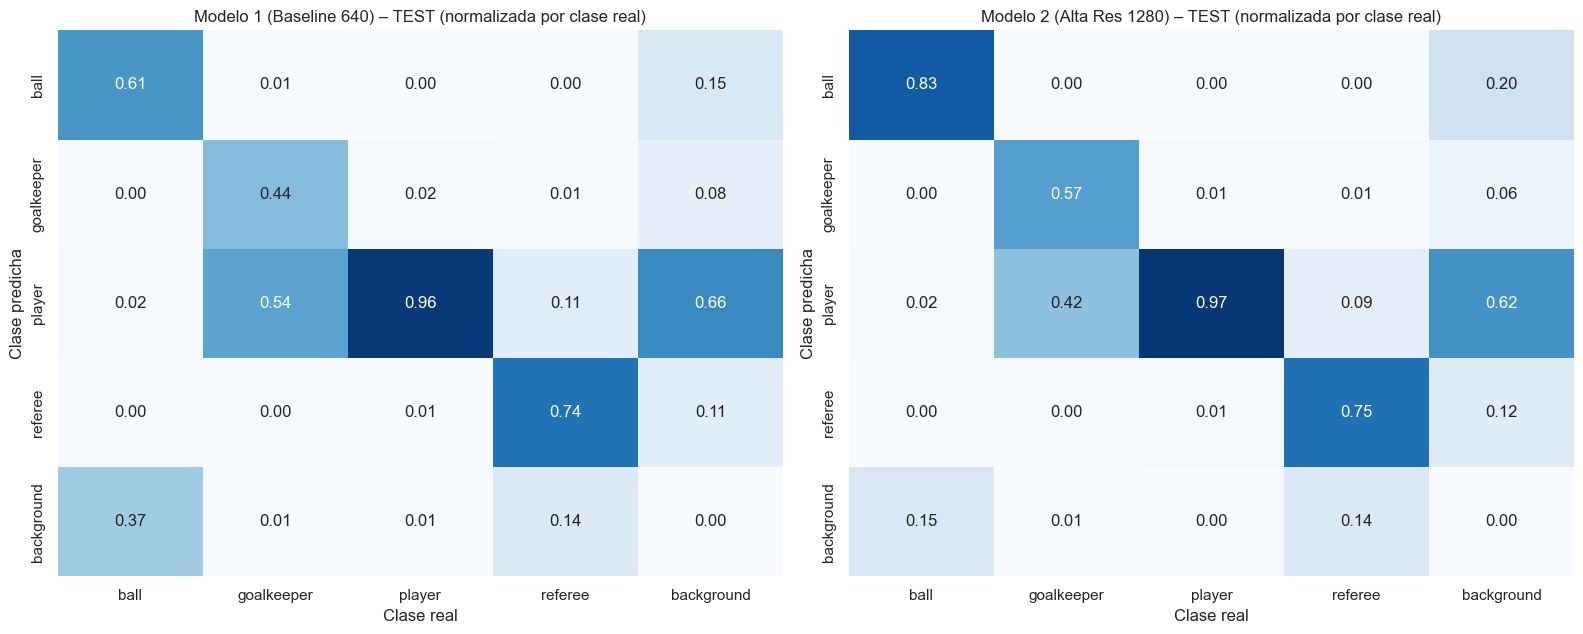

Modelo 1 (Baseline 640):
  Pelotas no detectadas (ball → background): 36.6%
  Arqueros confundidos con jugador (goalkeeper → player): 54.4%
Modelo 2 (Alta Res 1280):
  Pelotas no detectadas (ball → background): 14.5%
  Arqueros confundidos con jugador (goalkeeper → player): 41.7%


In [15]:
# Matriz de confusión en TEST: Modelo 1 vs Modelo 2 (ganador)
names_cm = class_names + ["background"]
modelos_cm = ["Modelo 1 (Baseline 640)", "Modelo 2 (Alta Res 1280)"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
for ax, m_name in zip(axes, modelos_cm):
    cm = val_results[("test", m_name)].confusion_matrix.matrix   # filas = predicho, columnas = real
    col_sum = cm.sum(axis=0, keepdims=True)
    cm_norm = np.divide(cm, col_sum, out=np.zeros_like(cm, dtype=float), where=col_sum > 0)

    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
                xticklabels=names_cm, yticklabels=names_cm, ax=ax, cbar=False)
    ax.set_xlabel("Clase real")
    ax.set_ylabel("Clase predicha")
    ax.set_title(f"{m_name} – TEST (normalizada por clase real)")

plt.tight_layout()
plt.show()

# Los dos números clave del TP
i_ball, i_gk, i_pl, i_bg = 0, 1, 2, 4
for m_name in modelos_cm:
    cm = val_results[("test", m_name)].confusion_matrix.matrix
    n = cm.sum(axis=0)
    print(f"{m_name}:")
    print(f"  Pelotas no detectadas (ball → background): {cm[i_bg, i_ball] / n[i_ball]:.1%}")
    print(f"  Arqueros confundidos con jugador (goalkeeper → player): {cm[i_pl, i_gk] / n[i_gk]:.1%}")

Se confirma la hipótesis de que jugador y arquero son los que más se cofunden. Luego, el 0,66 o 0,62 de background|player, quiere decir que de las veces que el modelo "inventa" una detección (está leyendo algo del fondo como si fuera una de las clases), la asocia con jugador. Tiene sentido porque jugador es la clase más detectada y es muy probable que en el fondo hayan otras personas que pasen como jugadores.

| Test (matriz de confusión) | M1 (640) | M2 (1280) |
|---|---|---|
| Pelotas detectadas (diagonal) | 61 % | **83 %** |
| Pelotas perdidas (ball → background) | 37 % | **15 %** |
| Arqueros bien clasificados | 44 % | 57 % |
| Arqueros tomados por jugador | 54 % | 42 % |

## 7. Etapa 05: Posprocesamiento (calibración de `conf` e `iou`)

Elegimos el umbral de confianza y el IoU del NMS con el modelo de la aplicación (M2, 1280, FP16). Para cada `iou` se corre el modelo una vez con confianza mínima, y los distintos `conf` se evalúan filtrando esas detecciones. El criterio es el F1 promedio de las 4 clases; se elige en validación y se confirma en test.


In [32]:
# se parte de valores estimados para luego comparar
CONF_OPT = 0.35
IOU_OPT = 0.60

print(f"🎯 Parámetros de Posprocesamiento Validados:")
print(f"  • Confidence Threshold: {CONF_OPT}")
print(f"  • NMS IoU Threshold:    {IOU_OPT}")


🎯 Parámetros de Posprocesamiento Validados:
  • Confidence Threshold: 0.35
  • NMS IoU Threshold:    0.6


A continuación se realiza un barrido de conf e IoU para detectar el punto óptimo de sus valores

In [33]:
# Se elige en VALIDACIÓN y se confirma una única vez en TEST.

import logging
from ultralytics.utils import LOGGER

def iou_1vN(a, b):
    """IoU entre una caja a y varias cajas b (formato xyxy)."""
    inter = (np.clip(np.minimum(a[2], b[:, 2]) - np.maximum(a[0], b[:, 0]), 0, None) *
             np.clip(np.minimum(a[3], b[:, 3]) - np.maximum(a[1], b[:, 1]), 0, None))
    return inter / ((a[2] - a[0]) * (a[3] - a[1]) + (b[:, 2] - b[:, 0]) * (b[:, 3] - b[:, 1]) - inter)

def detecciones_tp(model, img_list_txt, iou_nms):
    """Predice una sola vez con conf=0.01 y marca cada detección como TP o FP (misma clase, IoU >= 0.5)."""
    filas, n_gt = [], np.zeros(len(class_names), int)
    for p in [l.strip() for l in open(img_list_txt) if l.strip()]:
        lines = [l.split() for l in open(Path(p).parent.parent / "labels" / f"{Path(p).stem}.txt")]
        if any(len(l) != 5 for l in lines):
            continue                                   # etiqueta inválida (también la ignora Ultralytics)
        gt = np.array(lines, dtype=float).reshape(-1, 5)
        res = model.predict(p, imgsz=1280, conf=0.01, iou=iou_nms, half=True,
                            max_det=1000, device=DEVICE, verbose=False)[0]
        h, w = res.orig_shape
        g_cls = gt[:, 0].astype(int)
        g_box = np.c_[(gt[:, 1] - gt[:, 3] / 2) * w, (gt[:, 2] - gt[:, 4] / 2) * h,
                      (gt[:, 1] + gt[:, 3] / 2) * w, (gt[:, 2] + gt[:, 4] / 2) * h]
        n_gt += np.bincount(g_cls, minlength=len(class_names))
        usado = np.zeros(len(g_cls), bool)
        for k in res.boxes.conf.argsort(descending=True).tolist():   # de mayor a menor confianza
            box, c = res.boxes.xyxy[k].cpu().numpy(), int(res.boxes.cls[k])
            cand = np.where((g_cls == c) & ~usado)[0]
            tp = False
            if len(cand):
                ious = iou_1vN(box, g_box[cand])
                if ious.max() >= 0.5:
                    usado[cand[ious.argmax()]] = tp = True
            filas.append((c, float(res.boxes.conf[k]), tp))
    return pd.DataFrame(filas, columns=["cls", "conf", "tp"]), n_gt

def metricas(dets, n_gt, conf):
    """P, R y F1 por clase quedándose solo con las detecciones de confianza >= conf."""
    d = dets[dets["conf"] >= conf]
    tp = d.groupby("cls")["tp"].sum().reindex(range(len(class_names)), fill_value=0).values
    n_det = d.groupby("cls").size().reindex(range(len(class_names)), fill_value=0).values
    P, R = tp / np.maximum(n_det, 1), tp / n_gt
    return pd.DataFrame({"P": P, "R": R, "F1": 2 * P * R / np.maximum(P + R, 1e-9)}, index=class_names)

model_vid = YOLO(str(best_m2_path))
nivel_previo = LOGGER.level
LOGGER.setLevel(logging.ERROR)

# 1) Barrido en validación: una pasada del modelo por cada iou; los conf se prueban filtrando
filas = []
for iou_nms in [0.5, 0.6, 0.7, 0.8]:
    dets, n_gt = detecciones_tp(model_vid, split_files_map["valid"], iou_nms)
    for c in np.round(np.arange(0.05, 0.91, 0.05), 2):
        m = metricas(dets, n_gt, c)
        filas.append({"iou": iou_nms, "conf": c, "F1 macro": m["F1"].mean(),
                      "P ball": m.loc["ball", "P"], "R ball": m.loc["ball", "R"],
                      "R player": m.loc["player", "R"]})
barrido = pd.DataFrame(filas)

mejor = barrido.loc[barrido["F1 macro"].idxmax()]
CONF_OPT, IOU_OPT = float(mejor["conf"]), float(mejor["iou"])

print("VALIDACIÓN – mejor conf para cada iou (criterio: F1 macro):")
display(barrido.loc[barrido.groupby("iou")["F1 macro"].idxmax()].round(3))
print("VALIDACIÓN – configuración original (conf=0.35, iou=0.6):")
display(barrido[(barrido["iou"] == 0.6) & (barrido["conf"] == 0.35)].round(3))

# 2) Confirmación en test con la configuración elegida
dets_t, n_gt_t = detecciones_tp(model_vid, split_files_map["test"], IOU_OPT)
LOGGER.setLevel(nivel_previo)

print(f"\n✅ TEST con conf = {CONF_OPT}, iou = {IOU_OPT}:")
display(metricas(dets_t, n_gt_t, CONF_OPT).round(3))

VALIDACIÓN – mejor conf para cada iou (criterio: F1 macro):


,iou,conf,F1 macro,P ball,R ball,R player
5,0.5,0.3,0.828,0.814,0.687,0.970
23,0.6,0.3,0.827,0.803,0.687,0.971
43,0.7,0.4,0.823,0.824,0.652,0.967
61,0.8,0.4,0.810,0.746,0.653,0.968


VALIDACIÓN – configuración original (conf=0.35, iou=0.6):


,iou,conf,F1 macro,P ball,R ball,R player
24,0.6,0.35,0.826,0.827,0.676,0.97



✅ TEST con conf = 0.3, iou = 0.5:


,P,R,F1
ball,0.824,0.682,0.746
goalkeeper,0.725,0.909,0.806
player,0.964,0.962,0.963
referee,0.713,0.788,0.748


El F1 macro en validación es prácticamente igual en toda la zona `conf` ∈ [0,30; 0,40], `iou` ∈ [0,5; 0,7] (0,823–0,828): el sistema es robusto a la elección de umbrales. Se adopta el mejor punto medido, `conf = 0.30` e `iou = 0.5`; la configuración original (0,35 / 0,6) da 0,826.


## 8. Etapa 06: Aplicación en Video con HUD

Procesamos un clip de 30 s de la DFL Bundesliga Data Shootout (Kaggle, 1080p a 25 FPS) con el modelo elegido (M2, 1280, FP16) y los umbrales calibrados en la sección 7. Cada cuadro se anota con las cajas, un HUD con el conteo por clase y los FPS medidos, y se guarda en un video MP4 que se usa en la demo.

In [31]:
# 8. Aplicación en video: M2 (1280, FP16) con los umbrales calibrados en la sección 7
import time
from ultralytics.utils import LOGGER

#video_input = SHARED_DIR / "data" / "sample_match_15s.mp4"          # lectura: carpeta compartida
video_input = DEMO_VIDEO
video_output = OUT_DIR / "video" / "partido_anotado.mp4"             # escritura: carpeta propia
video_output.parent.mkdir(parents=True, exist_ok=True)

video_model = YOLO(str(best_m2_path))     # la existencia de los pesos ya se verificó en la evaluación

CLASS_COLORS_BGR = {0: (0, 215, 255),     # ball: amarillo
                    1: (255, 200, 0),     # goalkeeper: cian
                    2: (113, 204, 46),    # player: verde
                    3: (60, 76, 231)}     # referee: rojo

cap = cv2.VideoCapture(str(video_input))
w, h = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps_video = cap.get(cv2.CAP_PROP_FPS) or 25.0
writer = cv2.VideoWriter(str(video_output), cv2.VideoWriter_fourcc(*"mp4v"), fps_video, (w, h))

frame_times, preview_frames = [], []
fps_hud, frame_count = None, 0

nivel_previo = LOGGER.level
LOGGER.setLevel(logging.ERROR)     # silencia el warning de 'half' que se repite constantemente

while True:
    ret, frame = cap.read()
    if not ret:
        break
    frame_count += 1
    t0 = time.perf_counter()

    preds = video_model.predict(frame, imgsz=1280, half=True, conf=CONF_OPT, iou=IOU_OPT,
                                agnostic_nms=True,   # una sola caja por persona (evita jugador y arquero superpuestos)
                                device=DEVICE, verbose=False)[0]

    annotated = frame.copy()
    counts = {name: 0 for name in class_names}
    for box in preds.boxes:
        cls_id = int(box.cls[0])
        counts[class_names[cls_id]] += 1
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
        color = CLASS_COLORS_BGR[cls_id]
        cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 2)
        cv2.putText(annotated, f"{class_names[cls_id]} {float(box.conf[0]):.2f}", (x1, max(12, y1 - 4)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1, cv2.LINE_AA)

    # Tiempo del cuadro (inferencia + dibujado) y FPS suavizado para mostrar en pantalla
    dt = time.perf_counter() - t0
    frame_times.append(dt)
    fps_hud = 1 / dt if fps_hud is None else 0.9 * fps_hud + 0.1 / dt

    cv2.rectangle(annotated, (0, 0), (w, 30), (20, 20, 20), -1)
    hud = (f"Jugadores: {counts['player']} | Arqueros: {counts['goalkeeper']} | "
           f"Arbitros: {counts['referee']} | Pelota: {'SI' if counts['ball'] else 'NO'} | {fps_hud:.0f} FPS")
    cv2.putText(annotated, hud, (10, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 255), 1, cv2.LINE_AA)

    writer.write(annotated)
    if frame_count in (50, 150, 250, 350):
        preview_frames.append((frame_count, cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)))

cap.release()
writer.release()
LOGGER.setLevel(nivel_previo)

t_ms = np.array(frame_times[10:]) * 1000      # se descartan los primeros cuadros (calentamiento de la GPU)
print(f"🎬 Video guardado en: {video_output}")
print(f"⏱️ Inferencia + dibujado: {t_ms.mean():.1f} ms/cuadro → {1000 / t_ms.mean():.0f} FPS "
      f"(el video original va a {fps_video:.0f} FPS)")


🎬 Video guardado en: /content/drive/MyDrive/VpC2_salidas/video/partido_anotado.mp4
⏱️ Inferencia + dibujado: 30.1 ms/cuadro → 33 FPS (el video original va a 25 FPS)


### 8.1 Visualización de Cuadros del Video Anotado


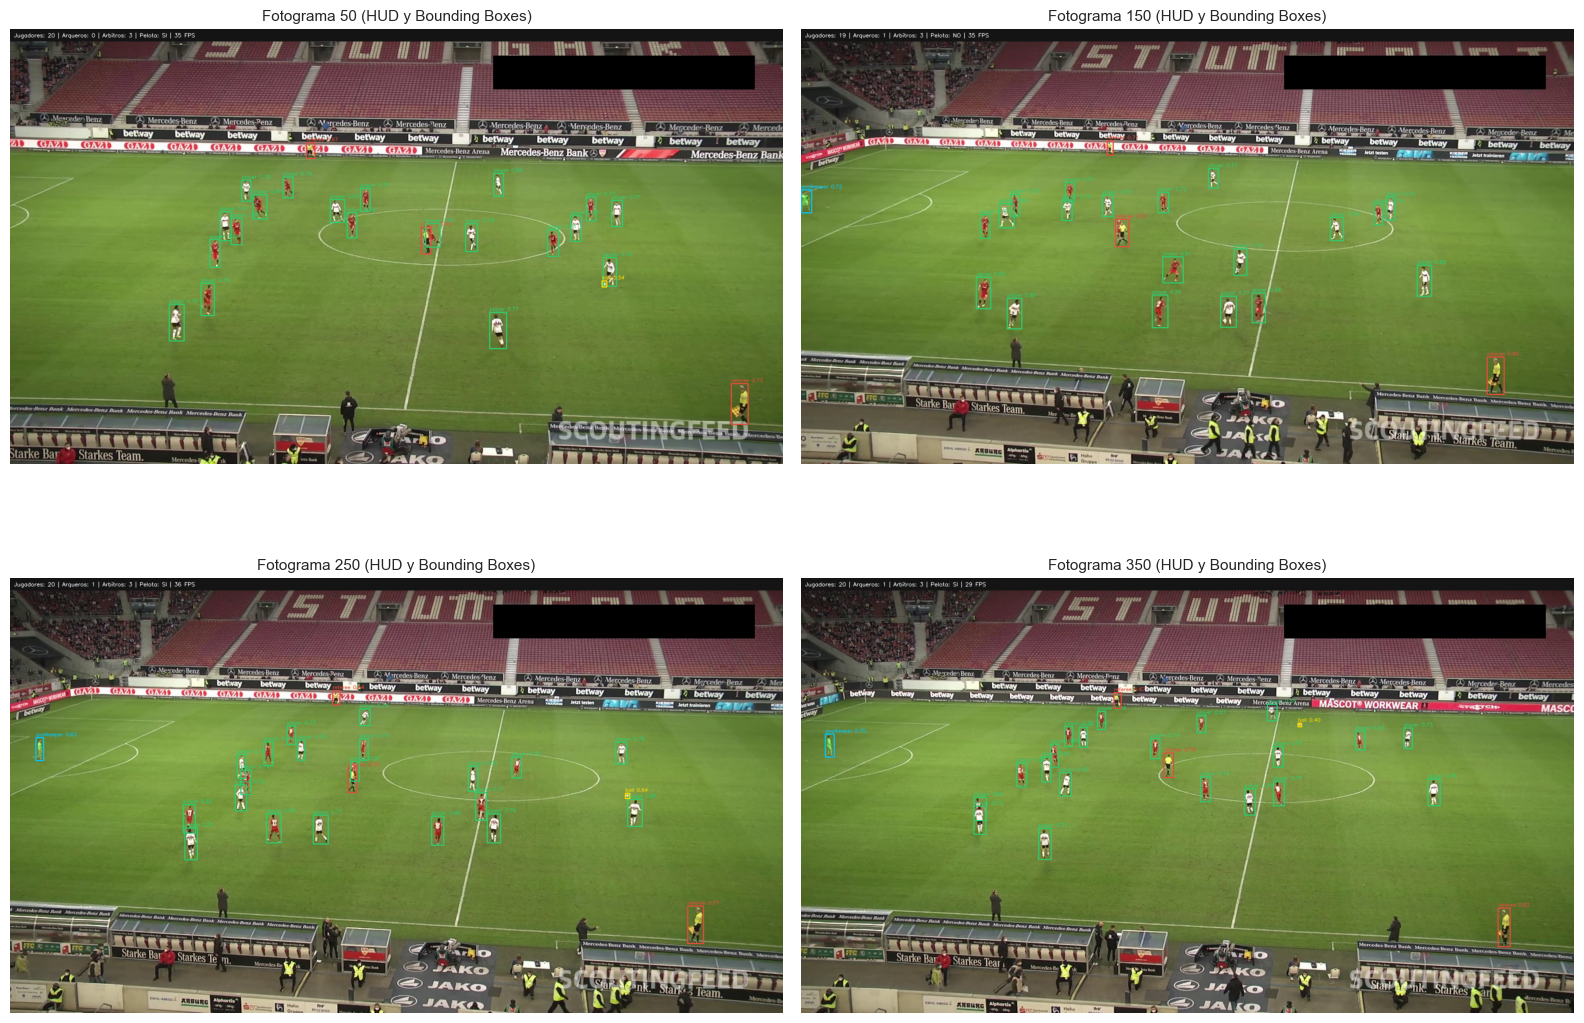

In [30]:
# Mostrar fotogramas representativos del video resultante
if preview_frames:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()
    for idx, (f_no, img_rgb) in enumerate(preview_frames[:4]):
        axes[idx].imshow(img_rgb)
        axes[idx].axis("off")
        axes[idx].set_title(f"Fotograma {f_no} (HUD y Bounding Boxes)", fontsize=11)
    plt.tight_layout()
    plt.show()


### 9. Conclusiones y Resumen del Trabajo Práctico

📌 **Conclusiones Clave:**

1. **Curación del Dataset y Reproducibilidad:** Se detectaron y purgaron 2.620 imágenes vacías que carecían de etiquetas, y se estableció un subconjunto representativo del 50% de la base (25.412 imágenes: 22.174 train / 2.220 valid / 1.018 test). La fijación de semillas (`seed=42`) garantizó un flujo de experimentación ágil y reproducible: al re-ejecutar el notebook en otra sesión se obtuvieron splits y métricas idénticos.

2. **Evaluación de las 3 Arquitecturas (test):**
   * **Modelo 1 (Baseline 640):** Ofrece excelente velocidad de inferencia (8,9 ms por frame en FP16) pero sufre con la pelota en tomas abiertas: AP50 de 0,51 y recall de 0,49. A 640 px la pelota mide ~5 px, menos que una celda de la grilla más fina (stride 8).
   * **Modelo 2 (Alta Resolución 1280):** Mitiga la degradación espacial de la pelota: sube su AP50 a 0,70 y su recall a 0,73, con el mejor mAP@50 global (0,747). El costo es computacional: es el más lento (60,7 ms en FP32). Esta variante demostró ser la estrategia técnica más efectiva para maximizar la detección del balón y es la elegida para el sistema final.
   * **Modelo 3 (Cabeza P2 640):** La cabeza extra de stride 4 apuntaba a retener características de alta resolución para objetos diminutos, pero en la práctica mejora poco la pelota (AP50 0,58) y es ~1,8 veces más lento que el M1. Por lo tanto, no resultó un buen compromiso. Las curvas muestran que convergió, así que no se explica por falta de entrenamiento. Una hipótesis es que las features de stride 4 vienen de capas tempranas, con detalle espacial pero poca información semántica.

3. **Análisis de la Matriz de Confusión y Desbalance (M2 en test, comparado con M1):** La evaluación expuso los efectos del tamaño de los objetos y del desequilibrio de clases:
   * **Jugadores (Player):** Al ser la clase dominante (>85% de las instancias), el modelo la asimila muy bien: AP50 ≈ 0,98 en los tres modelos y 96% de recall y precisión con los umbrales finales.
   * **Arqueros (Goalkeeper):** Es la mayor confusión entre clases. El 42% de los arqueros se clasifica como jugador de campo (54% en el M1), y solo el 57% se detecta correctamente. Esto refleja el desbalance del dataset (el arquero es apenas el 2,5% de las instancias) y la similitud visual entre ambas clases. Es un problema semántico, no de resolución: el AP50 del arquero no mejora con más resolución (0,67–0,71 en los tres modelos).
   * **Pelota (Ball):** Es donde más se nota la resolución. El M2 detecta el balón el 83% de las veces, frente al 61% del M1, y las pelotas que pasan desapercibidas (fondo/background) bajan del 37% al 15%. Esto confirma que el problema de la pelota es de tamaño (~5 px a 640) y que la resolución de entrada es la palanca principal.
   * **Árbitros (Referee):** Presentan un rendimiento razonable: solo un 14% pasa desapercibido y un 9–11% se confunde con jugadores de campo.
   * **Falsos positivos:** Cerca del 65% de los falsos positivos son predicciones de "jugador" sin etiqueta asociada. Probablemente sean personas reales no anotadas (suplentes, cuerpo técnico), lo que penaliza la precisión sin ser errores reales del modelo.

4. **Posprocesamiento Estratégico:** En lugar de fijar los umbrales a mano, se hizo un barrido de confianza (0,05–0,90) e IoU del NMS (0,5–0,8) sobre validación, maximizando el F1 macro. El F1 resultó prácticamente constante en una zona amplia (0,81–0,83), lo que indica un sistema robusto a la elección de umbrales. Se eligió `conf=0.30` e `iou=0.5`, y en test el sistema detecta el 68% de las pelotas con 82% de precisión. Contrario a la hipótesis inicial, el IoU del NMS no afecta a los jugadores (recall ≈ 0,97 en todos los valores probados), así que no se observó que se anularan mutuamente durante forcejeos. Un IoU alto (0,8), en cambio, genera cajas duplicadas de pelota. En el video se activó además el NMS agnóstico a la clase (`agnostic_nms=True`), para evitar que un mismo arquero aparezca con dos cajas (arquero y jugador).

5. **Persistencia y Resiliencia:** El uso de `save_period=5` y el almacenamiento directo en Google Drive garantizan que el entrenamiento pueda reanudarse sin pérdidas ante los límites de sesión o desconexiones propias de Colab. Se separó además la carpeta compartida de lectura (pesos y runs) de la carpeta de salidas de cada integrante, para que cualquiera pueda ejecutar el notebook sin escribir sobre el trabajo de otro.

6. **Viabilidad en Tiempo Real:** En una GPU T4 con batch=1, el M2 en FP32 procesa solo 16,5 FPS, por debajo de los 25 FPS del video. En FP16 llega a 43 FPS sin pérdida apreciable de precisión (mAP@50 0,747 → 0,746). El pipeline completo sobre video 1080p (inferencia y dibujado) alcanza 33 FPS, suficiente para procesar el partido en tiempo real.

7. **Limitaciones y Trabajo Futuro:** El mAP@50-95 de la pelota sigue siendo bajo, porque en cajas de ~5 px un error de 1 px reduce mucho el IoU. El clip de la demo proviene de la misma fuente (DFL Bundesliga) que parte del dataset, por lo que su rendimiento podría ser optimista. Como trabajo futuro se propone incorporar tracking (por ejemplo, ByteTrack) para dar continuidad a la pelota entre frames y asignar identidades a los jugadores, y sumar más ejemplos de arqueros.


---
### 👥 Grupo 11 – Visión por Computadora II – CEIA – FIUBA
